<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)

1) Load dataset

In [18]:
df = pd.read_csv("Crop_training_data_full.csv")
print(df.shape)
df.head()

# Target
y = df["suitability_class"].map({"Unsuitable": 0, "Suitable": 1})

# Features: drop target + score (score is derived, keep it OUT to avoid leakage)
X = df.drop(columns=["suitability_class", "suitability_score"])

(2100, 18)


In [19]:
categorical_cols = ["crop", "texture", "texture_tolerance", "rooting_depth", "sun_req"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

2) Preprocess


In [20]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


3) Pipeline model

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

4) Train/test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model.fit(X_train, y_train)



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'texture',
                                                   'texture_tolerance',
                                                   'rooting_depth',
                                                   'sun_req']),
                                                 ('num', 'passthrough',
                                                  ['temperature', 'rainfall',
                                                   'ph', 'organic_carbon',
                                                   'cec', 'awc', 'bulk_density',
                                                   'texture_num',
                                                   'texture_tol_num',
                                                   'root_depth_num',
                                                   'sun_req_num'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Accuracy: 0.8928571428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       162
           1       0.90      0.93      0.91       258

    accuracy                           0.89       420
   macro avg       0.89      0.88      0.89       420
weighted avg       0.89      0.89      0.89       420


Confusion Matrix:
 [[136  26]
 [ 19 239]]


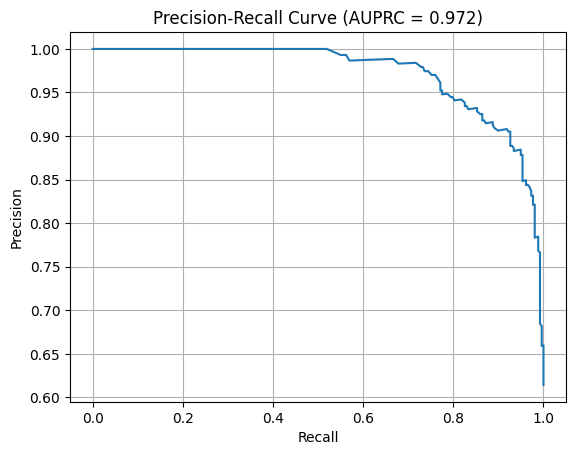

In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.3f})")
plt.grid(True)
plt.show()

In [25]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, average_precision_score

df = pd.read_csv("Crop_training_data_full.csv")

y = df["suitability_class"].map({"Unsuitable": 0, "Suitable": 1})
X = df.drop(columns=["suitability_class", "suitability_score"])

categorical_cols = ["crop", "texture", "texture_tolerance", "rooting_depth", "sun_req"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [None, 20, 40],
    "rf__min_samples_split": [2, 10],
    "rf__min_samples_leaf": [1, 4],
    "rf__max_features": ["sqrt", 0.5],
    "rf__bootstrap": [True]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("\n Best Params:\n", grid.best_params_)
print(" Best CV Score (AUPRC):", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUPRC:", average_precision_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits

 Best Params:
 {'rf__bootstrap': True, 'rf__max_depth': 20, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 500}
 Best CV Score (AUPRC): 0.969831925407693

Test Accuracy: 0.8666666666666667
Test AUPRC: 0.9656964021248637

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       162
           1       0.89      0.89      0.89       258

    accuracy                           0.87       420
   macro avg       0.86      0.86      0.86       420
weighted avg       0.87      0.87      0.87       420



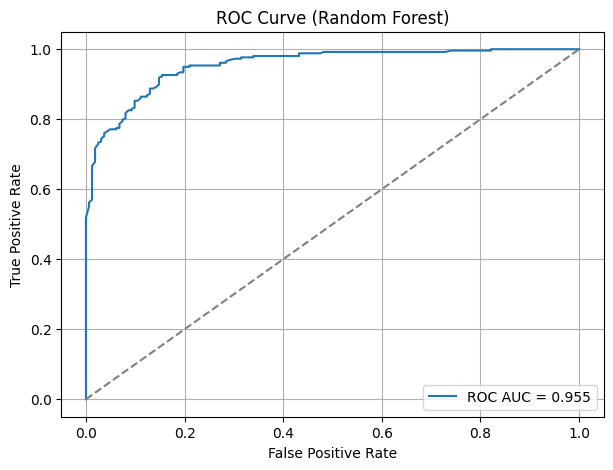

ROC AUC Score: 0.955


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for the positive class
y_proba = model.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {roc_auc:.3f}")
